In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import os
import contextily as ctx

In [2]:
from airquality import datamodules as datamodules
from airquality.datamodules.data_load.load_zcta_data import load_zcta_data

id = 'airquality_coi_daily'
config = datamodules.spec(id).default_config.copy()
config['preprocessing_config']['threshold'] = 100
datamodule = datamodules.make('airquality_coi_daily', **config)
datamodule.setup('none')

zctas = datamodule.df['ZCTA5CE20'].unique()

zcta_df = load_zcta_data().loc[zctas]
print(f'Loaded {len(zcta_df)} ZCTAs')

chkd_gdf = gpd.read_file(os.path.join(os.environ['DATA_DIR'], 'chkd_sites/chkd_site_addresses.shp'))
chkd_gdf = chkd_gdf.rename(columns={'HEALTH_CAR': 'HEALTH_CARE_SITE'}).drop(columns='Address')

air_df = pd.read_csv(os.path.join(os.environ['DATA_DIR'], 'all_fed_ref_monitor.csv'), usecols=['site_number', 'latitude', 'longitude'])
air_df = air_df.groupby('site_number').agg('first')
air_gdf = gpd.GeoDataFrame(air_df, geometry=gpd.points_from_xy(air_df.longitude, air_df.latitude))

Loaded 42 ZCTAs


In [3]:
# Get weather station locations
from glob import glob
import warnings
warnings.filterwarnings('ignore')
paths = sorted(glob(f'{os.environ["DATA_DIR"]}/NOAA_local_climatological_data_v2/LCD_*.csv'))

station_dfs = []
for path in paths:
    if '03739' in path: continue # Skip Cape Charles
    weather_df = pd.read_csv(path)
    station_df = weather_df.groupby('STATION').agg({'LATITUDE': 'first', 'LONGITUDE': 'first'})
    station_dfs.append(station_df)

station_dfs = pd.concat(station_dfs).drop_duplicates()
weather_df = gpd.GeoDataFrame(station_dfs, geometry=gpd.points_from_xy(station_dfs['LONGITUDE'], station_dfs['LATITUDE']))
weather_df.geometry = weather_df.geometry.set_crs('EPSG:4326')
weather_df

,LATITUDE,LONGITUDE,geometry
STATION,,,
USW00000154,36.78300,-76.45000,POINT (-76.45 36.783)
USW00003701,36.66556,-76.32056,POINT (-76.32056 36.66556)
USW00003719,36.68222,-76.60167,POINT (-76.60167 36.68222)
USW00003734,37.52111,-76.76472,POINT (-76.76472 37.52111)
USW00013702,37.08278,-76.36028,POINT (-76.36028 37.08278)
USW00013737,36.90330,-76.19220,POINT (-76.1922 36.9033)
USW00013750,36.93746,-76.28926,POINT (-76.28926 36.93746)
USW00013762,36.69500,-76.13556,POINT (-76.13556 36.695)
USW00013763,36.69806,-76.90306,POINT (-76.90306 36.69806)


In [4]:
cities = [
    'Norfolk',
    'Virginia Beach',
    'Chesapeake',
    'Portsmouth',
    'Suffolk',
    'Newport News',
    'Hampton'
]
latitude = [
    36.84937,
    36.84966,
    36.71683,
    36.83201,
    36.72813,
    36.97750,
    37.02644,
]
longitude = [
    -76.28995,
    -75.97075,
    -76.24945,
    -76.29770,
    -76.58347,
    -76.42977,
    -76.34429,
]

cities_df = gpd.GeoDataFrame(pd.DataFrame({'cities': cities}), geometry=gpd.points_from_xy(longitude, latitude))
cities_df

,cities,geometry
0,Norfolk,POINT (-76.28995 36.84937)
1,Virginia Beach,POINT (-75.97075 36.84966)
2,Chesapeake,POINT (-76.24945 36.71683)
3,Portsmouth,POINT (-76.2977 36.83201)
4,Suffolk,POINT (-76.58347 36.72813)
5,Newport News,POINT (-76.42977 36.9775)
6,Hampton,POINT (-76.34429 37.02644)


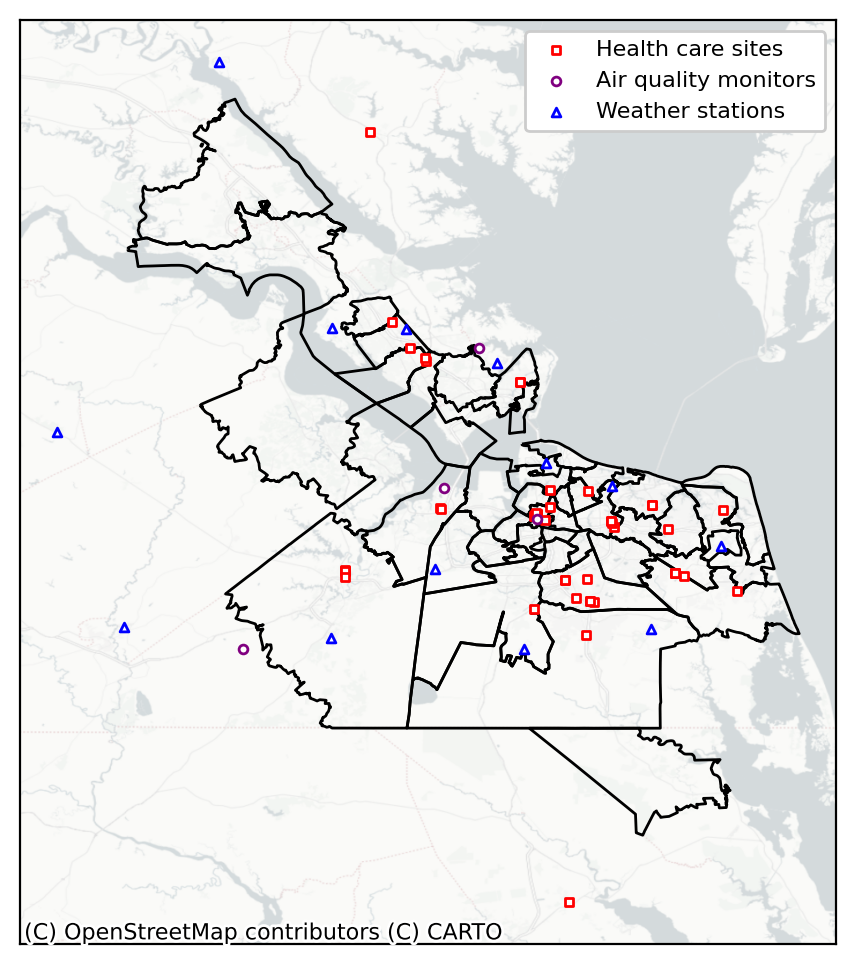

In [87]:
fig, ax = plt.subplots(1, 1, dpi=200, figsize=(6, 6))

zcta_df.plot(ax=ax, facecolor='none', edgecolor='black')
markersize = 10
chkd_gdf.plot(ax=ax, marker='s', color='red', markersize=markersize, facecolor='white', label='Health care sites')
air_gdf.plot(ax=ax, marker='o', color='purple', markersize=markersize, facecolor='white', label='Air quality monitors')
weather_df.plot(ax=ax, marker='^', color='blue', markersize=markersize, facecolor='white', label='Weather stations')
# cities_df.plot(ax=ax, marker='.', edgecolor='black', facecolor='white', label='Cities')
ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, crs=chkd_gdf.crs)
ax.set(
    #xlabel='Latitude', 
    # xlim=[-76.6, -75.95],
    xticks=[],
    #ylabel='Longitude', 
    # ylim=[36.65, 37.2],
    yticks=[],
    aspect='equal'
)

ax.legend(framealpha=1, fontsize=8)
plt.savefig(os.path.join(os.environ['MODELS_DIR'], 'study_map.pdf'), bbox_inches='tight')

In [6]:
shipping_names = [
    'Newport News Shipbuilding',
    'Norfolk Shipyard',
    'Lyon Shipyard',
    'Newport News Marine Terminal',
    'Virginia International Terminals',
    'Virginia International Gateway',
    'Porstmouth Marine Terminal',
    'Norfolk Southern Lamberts Point', 
    # 'Naval Station Norfolk',
]
shipping = np.array([
    [36.98977, -76.43649], # Newport News Shipbuilding
    [36.81682, -76.30442], # Norfolk Naval Shipyard
    [36.84296, -76.26922], # Lyon  Shipyard
    [36.96635, -76.41521], # Newport News Marine Terminal
    [36.91846, -76.32241], # Virginia International Terminals, Norfolk
    [36.87380, -76.35839], # Virginia International Gateway Portsmouth
    [36.85411, -76.32318], # Portsmouth Marine Terminal
    [36.87794, -76.32612], # Norfolk Southern
    # [36.94414, -76.31955], # Naval Station Norfolk
])

shipping_df = gpd.GeoDataFrame(index=shipping_names, geometry=gpd.points_from_xy(shipping[:, 1], shipping[:, 0]))
shipping_df

,geometry
Newport News Shipbuilding,POINT (-76.43649 36.98977)
Norfolk Shipyard,POINT (-76.30442 36.81682)
Lyon Shipyard,POINT (-76.26922 36.84296)
Newport News Marine Terminal,POINT (-76.41521 36.96635)
Virginia International Terminals,POINT (-76.32241 36.91846)
Virginia International Gateway,POINT (-76.35839 36.8738)
Porstmouth Marine Terminal,POINT (-76.32318 36.85411)
Norfolk Southern Lamberts Point,POINT (-76.32612 36.87794)


In [7]:
airport_names = [
    'Newport News Williamsburg',
    'Norfolk',
    'NAVSTA',
    'NAS Oceana',
    'Langley',
]
airports = np.array([
    [37.14515, -76.50383],
    [36.90329, -76.20214],
    [36.93732, -76.29266],
    [36.82043, -76.02645],
    [37.08367, -76.35948],
])

airports_df = gpd.GeoDataFrame(index=airport_names, geometry=gpd.points_from_xy(airports[:, 1], airports[:, 0]))
airports_df

,geometry
Newport News Williamsburg,POINT (-76.50383 37.14515)
Norfolk,POINT (-76.20214 36.90329)
NAVSTA,POINT (-76.29266 36.93732)
NAS Oceana,POINT (-76.02645 36.82043)
Langley,POINT (-76.35948 37.08367)


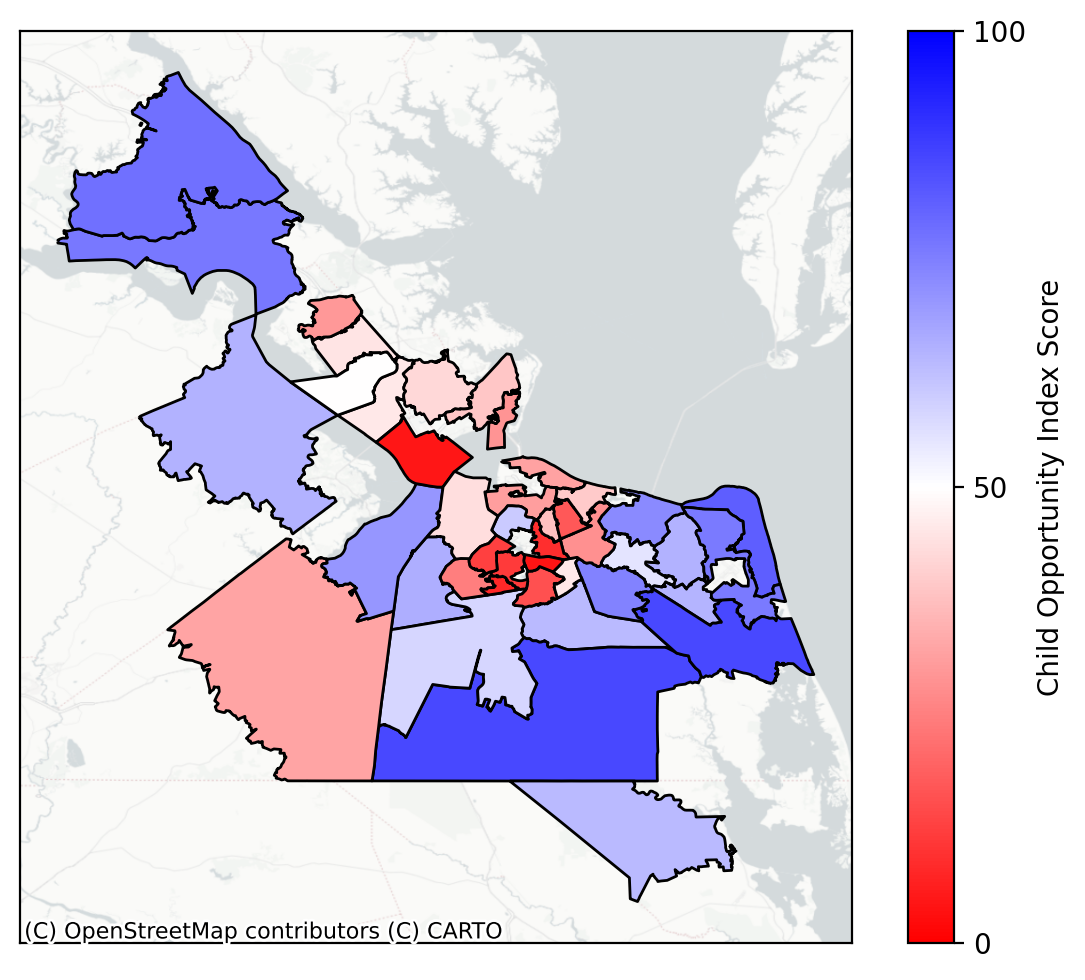

In [91]:
# Plot COI
toplot = zcta_df.merge(
    datamodule.dataframes['coi_df'].reset_index().groupby('ZCTA5CE20').agg({'COI_overall_perc': 'mean'}),
    left_index=True, right_index=True, how='inner')

fig, ax = plt.subplots(1, 1, dpi=200, figsize=(6, 5))

toplot.plot(ax=ax, column='COI_overall_perc', edgecolor='black', 
            cmap='bwr_r', vmin=0, vmax=100, 
            legend=True, legend_kwds={'label': 'Child Opportunity Index Score', 'ticks': [0, 50, 100]})
ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, crs=chkd_gdf.crs)

# cities_df.plot(ax=ax, marker='o', markersize=10, edgecolor='black', facecolor='white', label='Cities')
# shipping_df.plot(ax=ax, marker='s', markersize=10, edgecolor='black', facecolor='white', label='Shipyards & \nMarine Terminals')
# airports_df.plot(ax=ax, marker='^', markersize=10, edgecolor='black', facecolor='white', label='Airplanes')

# for x, y, label in zip(cities_df.geometry.x, cities_df.geometry.y, cities_df['cities']):
#     ax.text(x - 2e-2, y, label, fontsize=8, ha='right', va='center')

ax.set(
    xticks=[],
    yticks=[],
    aspect='equal'
)
xlim = ax.get_xlim()
ylim = ax.get_ylim()
plt.tight_layout()

# ax.legend(framealpha=1, fontsize=8)
plt.savefig(os.path.join(os.environ['MODELS_DIR'], 'coi_map.pdf'), bbox_inches='tight')

In [19]:
shipping_routes = gpd.read_file(os.path.join(os.environ['DATA_DIR'], 'US_Vessel_Traffic_2018_05.gdb'))
shipping_routes = shipping_routes.to_crs('EPSG:4326')

In [67]:
toplot.vessel_group.unique()

array(['Pleasure', 'Tow', 'Cargo', 'Other', 'Not Available', 'Passenger',
       'Fishing', 'Tanker', 'Military'], dtype=object)

In [68]:
import rasterio
from rasterio.features import geometry_mask
from shapely.geometry import mapping
from tqdm.auto import tqdm

x0, x1 = xlim[0], xlim[1]
y0, y1 = ylim[0], ylim[1]
dd = 0.005

Nx = int((x1 - x0) / dd)
Ny = int((y1 - y0) / dd)

toplot = shipping_routes.cx[x0:x1, y0:y1]
toplot = toplot[toplot.vessel_group.isin(['Tow', 'Cargo', 'Passenger', 'Tanker', 'Military'])]

raster = np.zeros([Ny, Nx], dtype=np.float32)
transform = rasterio.transform.from_origin(x0, y1, dd, dd)

for row in tqdm(toplot.geometry):
    mask = geometry_mask([mapping(row)], transform=transform, invert=True, out_shape=(Ny, Nx), all_touched=True)
    raster[mask] += 1


  0%|          | 0/16549 [00:00<?, ?it/s]

-0.13358136 34.164127 0.0 1.0


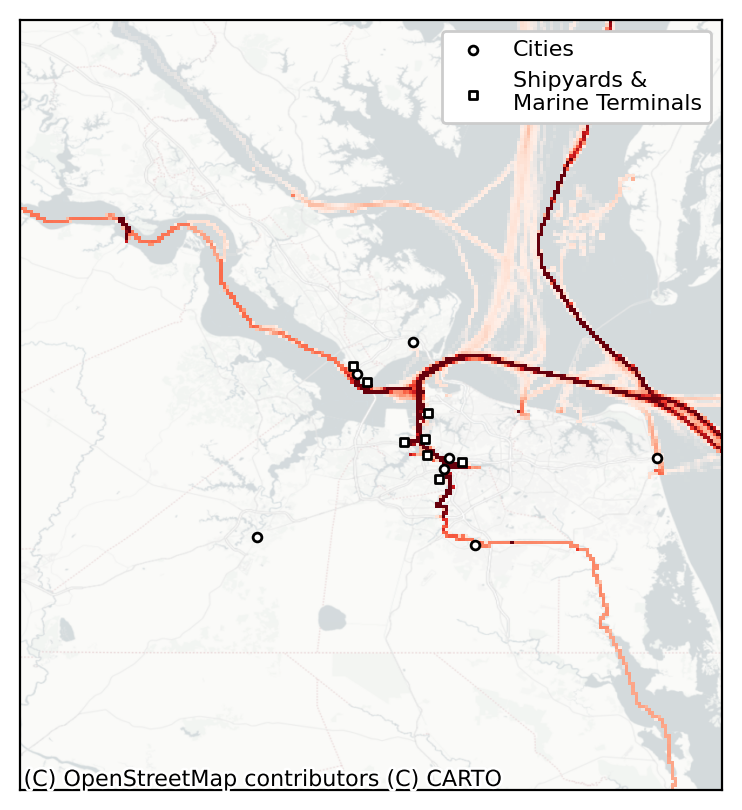

In [92]:
fig, ax = plt.subplots(1, 1, dpi=200, figsize=(6, 5))


z_score = (raster - raster.mean()) / raster.std()
print(z_score.min(), z_score.max(), z_score.mean(), z_score.std())
ax.imshow(z_score, vmin=0, vmax=5, 
          alpha=np.clip(z_score * 5, 0, 1),
          extent=[x0, x1, y0, y1],  cmap='Reds', zorder=1)

cities_df.plot(ax=ax, marker='o', markersize=10, edgecolor='black', facecolor='white', label='Cities')
shipping_df.plot(ax=ax, marker='s', markersize=10, edgecolor='black', facecolor='white', label='Shipyards & \nMarine Terminals')

ax.set(
    xlim = [x0, x1],
    ylim = [y0, y1],
    xticks=[],
    yticks=[],
)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, crs=chkd_gdf.crs)

ax.legend(framealpha=1, fontsize=8)

0.0 1694.0 6.597724 49.391052


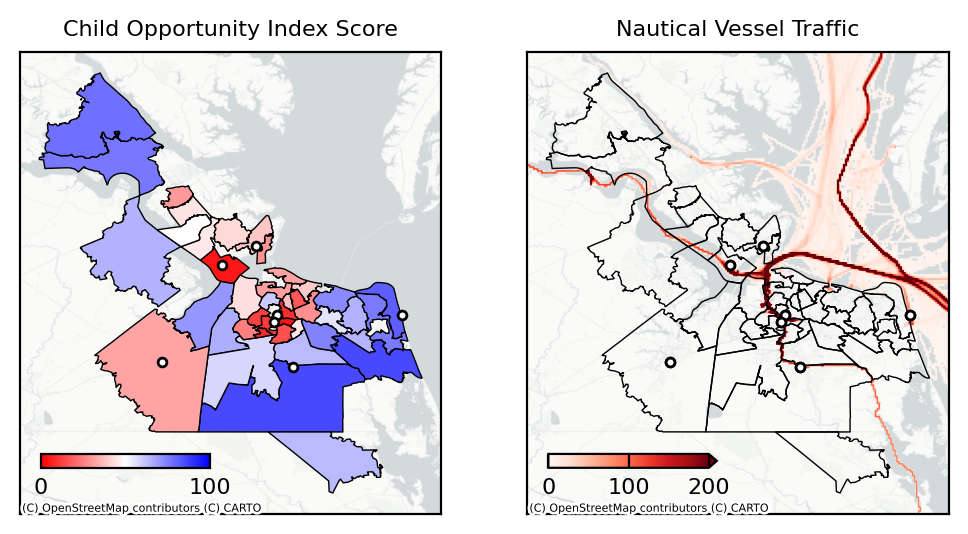

In [188]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl


fig, ax = plt.subplots(1, 2, dpi=200, figsize=(6, 3), sharex=True, sharey=True)

coi_df = zcta_df.merge(
    datamodule.dataframes['coi_df'].reset_index().groupby('ZCTA5CE20').agg({'COI_overall_perc': 'mean'}),
    left_index=True, right_index=True, how='inner')

norm = mpl.colors.Normalize(vmin=0, vmax=100)
cmap = plt.get_cmap('bwr_r')
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
coi_df.plot(ax=ax[0], column='COI_overall_perc', edgecolor='black', linewidth=0.5,
            cmap=cmap, norm=norm)

cax = ax[0].inset_axes( bounds=[0.05, 0.1, 0.4, 0.03])
cbar = plt.colorbar(sm, cax=cax, ticks=[0, 100], orientation='horizontal', extend='neither')
cbar.ax.tick_params(labelsize=8, length=0)
# cbar.set_label('COI Score', fontsize=8, labelpad=-4)
ax[0].set_title('Child Opportunity Index Score', fontsize=8)

xlim = ax[0].get_xlim()
ylim = ax[0].get_ylim()

print(raster.min(), raster.max(), raster.mean(), raster.std())

norm = mpl.colors.Normalize(vmin=0, vmax=200)
cmap = plt.get_cmap('Reds')
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
ax[1].imshow(raster, alpha=np.clip(raster, 0, 1),
          extent=[x0, x1, y0, y1], norm=norm, cmap=cmap, zorder=1)
zcta_df.plot(ax=ax[1], facecolor='none', edgecolor='black', linewidth=0.5)
cities_df.plot(ax=ax[1], marker='o', markersize=10, edgecolor='black', facecolor='white', label='Cities')
# shipping_df.plot(ax=ax[1], marker='s', markersize=10, edgecolor='black', facecolor='white', label='Shipyards & \nMarine Terminals')

cax = ax[1].inset_axes( bounds=[0.05, 0.1, 0.4, 0.03])
cbar = plt.colorbar(sm, cax=cax, ticks=[0, 100, 200], orientation='horizontal', extend='max')
cbar.ax.tick_params(labelsize=8, direction='in', length=5)
ax[1].set_title('Nautical Vessel Traffic', fontsize=8)

for a in ax:
    cities_df.plot(ax=a, marker='o', markersize=10, edgecolor='black', facecolor='white', label='Cities')
    ctx.add_basemap(a, source=ctx.providers.CartoDB.PositronNoLabels, crs=chkd_gdf.crs)
    a.set(xlim=xlim, ylim=ylim, xticks=[], yticks=[], aspect='equal')
    for txt in a.texts:
        txt.set_fontsize(4)

# ax[1].legend(framealpha=1, fontsize=8)
plt.savefig(os.path.join(os.environ['MODELS_DIR'], 'coi_map.pdf'), bbox_inches='tight')